- 비지도 학습의 가장 대표적인 모델은 Clustering
- 군집모델 중에서 가장 유명하지만 대표적인 모델이 KMeans(모델명) Clustering (유형)
- 정답(y)이 없는 데이터를 다루는 비지도학습
- KMeans로 데이터를 비슷한 그룹을 묶어줌
- Elbow 기법으로 적절한 Cluster(군집) 수(K)를 정하는 모델
    - KMeans 모델의 원리
        - 중심점 K개를 랜덤하게 찍음
        - 각 점을 가장 가까운 중심에 배정
        - 그룹의 "평균"으로 중심을 이동
        - 변화가 없을때까지 2~3회 반복
        - 정확도가 아니라 군집이 얼마나 잘 뭉쳐졌는지를 평가 

In [37]:
import os
os.environ['OMP_NUM_THREADS'] = "1"

import pandas as pd
import numpy as np

# 데이터셋 로드 
from sklearn.datasets import load_iris

# 훈련_테스트 데이터 스플릿 
from sklearn.model_selection import train_test_split

# 스케일링
from sklearn.preprocessing import StandardScaler

# K_Means_Clustering
from sklearn.cluster import KMeans 
from sklearn.metrics import confusion_matrix ,silhouette_score 
# confusion_matrix :
# silhouette_score : 

from sklearn.decomposition import PCA # decomposition : 분해 
# 차원 축소 

# 시각화 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [38]:
iris = load_iris()

In [39]:
X = iris.data # 정답이 없음  ==> y가 없다 
feature_names = iris.feature_names

print("사용할 입력 변수 : ")
print(feature_names)

print("\n입력 데이터 크기:",X.shape)

사용할 입력 변수 : 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

입력 데이터 크기: (150, 4)


In [40]:
df = pd.DataFrame(X,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 데이터 스케일링

In [5]:
scaler = StandardScaler()

In [41]:
# 변수를 평균 0, 표준편차 1 기준으로 변환
X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(X_scaled,columns=feature_names)
scaled_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [43]:
df.mean()

sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

In [44]:
scaled_df.mean()

sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

In [45]:
scaled_df.std()

sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64

### 5. Elbow Method로 K후보 탐색

- 군집 개수 K를 결정
- K를 바꾸면서 inertia를 확인
    - inertia : 각 데이터가 자신이 속한 군집 중심점에서 떨어진 거리의 합
    - 값이 작을수록 군집 내부가 조밀하다
    - K가 커질수록 inertia는 계속 감소
    - 감소폭이 갑자기 완만해지는 지점이 K후보

In [8]:
inertias = []

K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias
})

elbow_df

,K,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


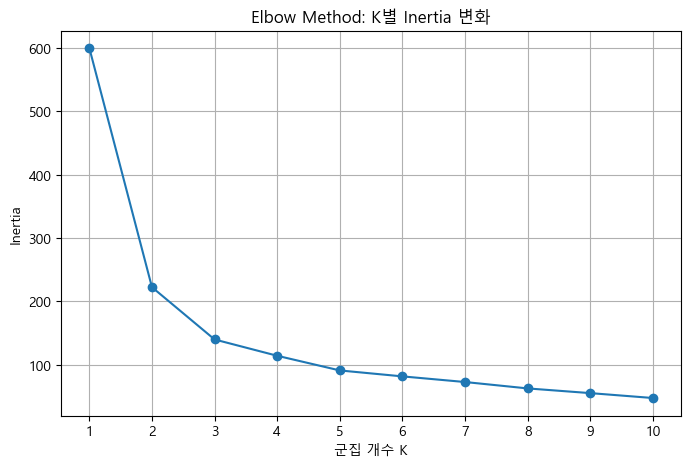

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_df["K"], elbow_df["Inertia"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Inertia 변화")
plt.xticks(list(K_range))
plt.grid()
plt.show()

elbow = 3으로 추정

### Clustering 모델 평가 지표 

1) Silhouette Score ( 실루엣 점수 )
     - 1에 가까울수록 좋음
     - 군집 내부는 가깝고 다른 군집과는 멀수록 높음
       

In [31]:
silhouette_results = []

# K=1은 실루엣 계산이 불가능하므로 K=2부터 시작 

for k in range(2,10) : 
    kmeans_temp = KMeans(
        n_clusters= k,
        random_state = 42,
        n_init = 10
    )

    # KMeans 학습 후 각 데이터의 군집 번호 예측 
    labels_temp = kmeans_temp.fit_predict(X_scaled)

    # Silouette Score 계산 
    sil = silhouette_score(X_scaled,labels_temp)

    # 결과 저장
    silhouette_results.append({
        "K" : k,
        "Silhouette_Score" : sil
    })
silhouette_df = pd.DataFrame(silhouette_results)

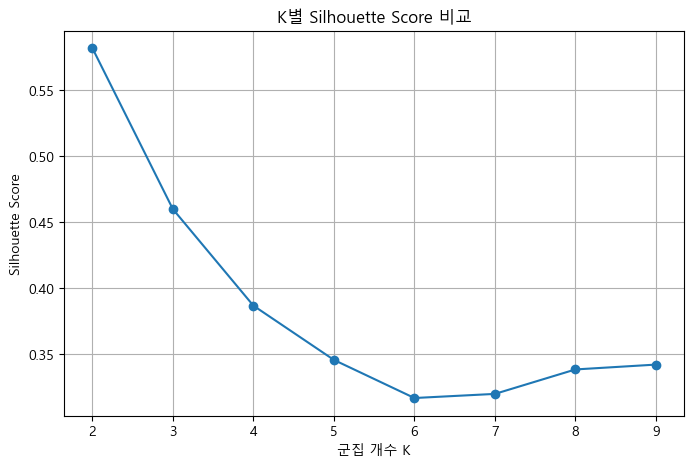

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("군집 개수 K")
plt.ylabel("Silhouette Score")
plt.title("K별 Silhouette Score 비교")
plt.xticks(silhouette_df["K"])
plt.grid(True)
plt.show()

In [46]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 42,
    n_init = 10
)

In [ ]:
cluster_labels = kmeans.fit_predict(X_scaled)

# 원본 데이터프레임에 군집 번호 추가
